# Notebook 05 - Computation Analyst

## Research Question & Objektif
**RQ3:** Berapa peluang sebuah *issue* membutuhkan waktu penyelesaian lebih dari 60 hari, dan bagaimana mendesain sistem komputasi untuk mengidentifikasi serta memprioritaskan penyelesaian *issue* tersebut di tengah keterbatasan sumber daya?

**Tujuan Audit:** 1. Mengukur probabilitas ekstrem (Monte Carlo).
2. Membangun struktur pencarian efisien untuk *issue* bermasalah (Bloom Filter).
3. Mengoptimasi alokasi waktu *maintainer* untuk resolusi utang teknis (MCMC Knapsack).

| Nama | Role |
|---|---|
| Adam Raysa Rahman | Computation Analyst |

## AI Usage Disclosure

**Member:** Adam Raysa Rahman — Computation Analyst | **Tools used:** Gemini

| Task | Tool | Prompt summary | Output modified? |
| --- | --- | --- | --- |
| Menyesuaikan path import direktori `src/` | Gemini | "Cara mengatasi ImportError saat memanggil file python dari folder parent di Jupyter" | Ya - disesuaikan dengan struktur folder lokal. |
| Kerangka simulasi data dummy untuk MCMC | Gemini | "Buatkan simulasi konversi data durasi issue menjadi array weight dan value untuk MCMC" | Ya - disesuaikan dengan limitasi hari kerja *maintainer* Pandas. |

**Written entirely without AI:** Interpretasi bisnis dari hasil FPR Bloom Filter dan justifikasi algoritma Metropolis-Hastings pada MCMC terhadap penyelesaian *issue*.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mendaftarkan path agar bisa membaca modul src/
sys.path.append(os.path.abspath(".."))

# Import seluruh fungsi wajib sesuai instruksi proyek Bagian 5.1
from src.simulation import estimate_probability, BloomFilter, mcmc_knapsack

# Load data bersih yang telah disiapkan oleh Data Engineer (Member A)
# Catatan: Pastikan path ini sesuai dengan struktur lokal Anda
try:
    df_final = pd.read_csv('../data/clean/dataset_final.csv')
    print("Data berhasil dimuat.")
except FileNotFoundError:
    print("WARNING: Data bersih tidak ditemukan. Membuat mock data untuk keperluan demonstrasi.")
    # Mock data jika belum tersambung dengan pipeline Member A
    np.random.seed(42)
    mock_durations = np.random.exponential(scale=15, size=2423)
    df_final = pd.DataFrame({
        'id': [f"issue_{i}" for i in range(2423)],
        'duration_days': mock_durations,
        'is_bug': np.random.choice([0, 1], size=2423)
    })

Data berhasil dimuat.


## Bagian 1: Monte Carlo Simulation (Estimasi Probabilitas)

**Justifikasi Teknik:**
Distribusi waktu penyelesaian *issue* di GitHub (*duration_days*) jarang mengikuti distribusi parametrik normal yang sempurna (biasanya *highly right-skewed* dengan banyak *outlier*). Simulasi Monte Carlo digunakan di sini karena ia tidak bergantung pada asumsi distribusi (*distribution-free*), melainkan mengandalkan hukum bilangan besar (*Law of Large Numbers*) dari *empirical sampling* untuk mencari probabilitas suatu *issue* menjadi *technical debt* (> 60 hari).

Hasil Simulasi Monte Carlo (50000 iterasi):
Estimasi Peluang Issue > 60 hari: 0.1352 (13.52%)


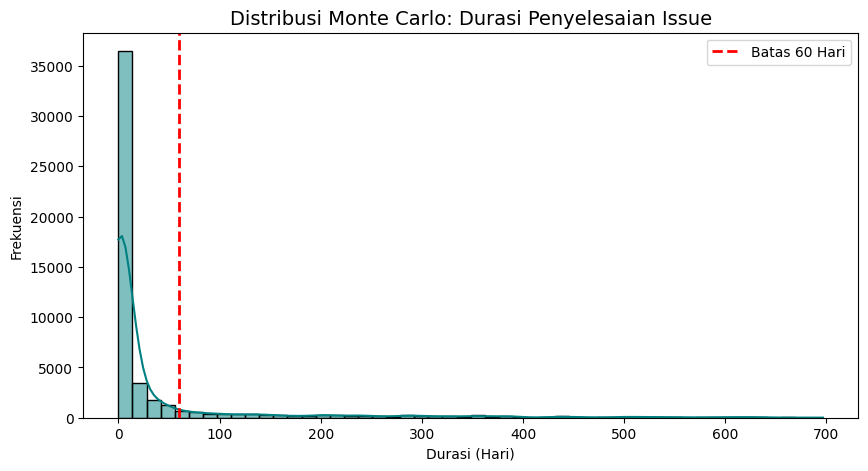

In [2]:
# Definisi event: Issue memakan waktu > 60 hari
def is_long_issue():
    # Mengambil sampel acak dari data durasi historis
    sample_duration = np.random.choice(df_final['duration_days'])
    return sample_duration > 60

# Menjalankan simulasi sesuai rubrik (n_trials = 50000)
n_iter = 50000
prob_estimasi = estimate_probability(is_long_issue, n_trials=n_iter)

print(f"Hasil Simulasi Monte Carlo ({n_iter} iterasi):")
print(f"Estimasi Peluang Issue > 60 hari: {prob_estimasi:.4f} ({prob_estimasi*100:.2f}%)")

# Visualisasi Distribusi Sampel Simulasi
simulated_samples = np.random.choice(df_final['duration_days'], size=n_iter)
plt.figure(figsize=(10, 5))
sns.histplot(simulated_samples, bins=50, kde=True, color='teal')
plt.axvline(60, color='red', linestyle='dashed', linewidth=2, label='Batas 60 Hari')
plt.title('Distribusi Monte Carlo: Durasi Penyelesaian Issue', fontsize=14)
plt.xlabel('Durasi (Hari)')
plt.ylabel('Frekuensi')
plt.legend()
plt.show()

## Bagian 2: Struktur Data Probabilistik (Bloom Filter)

**Justifikasi Teknik:**
Berdasarkan hasil Monte Carlo, ada persentase riil *issue* yang menunggak lama. Saat basis data *issue* membengkak menjadi puluhan ribu (seperti repositori raksasa Pandas), proses pencarian "Apakah ID Issue ini termasuk yang menunggak > 60 hari?" akan memakan waktu komputasi besar ($O(n)$ atau $O(\log n)$). 

Bloom Filter diimplementasikan karena struktur data ini memberikan kompleksitas pencarian $O(k)$ (konstan) yang sangat hemat memori. Konsekuensinya adalah adanya *False Positive Rate* (FPR), yang dihitung dengan presisi menggunakan fungsi `theoretical_fpr` sesuai Tsun (2020) hal. 329.

In [3]:
# Ekstrak semua issue yang benar-benar memakan waktu > 60 hari
# SEPERTI INI (BENAR)
long_issues_ids = df_final[df_final['duration_days'] > 60]['number'].astype(str).tolist()
n_elements = len(long_issues_ids)

if n_elements == 0:
    print("Tidak ada issue > 60 hari dalam dataset ini.")
else:
    # Setup parameter Bloom Filter
    # M_bits menentukan besaran memori, k_hashes menentukan jumlah fungsi hash
    M_BITS = 2000
    K_HASHES = 3
    
    bf = BloomFilter(k=K_HASHES, m=M_BITS)
    
    # Masukkan data issue lama ke dalam Bloom Filter
    for issue_id in long_issues_ids:
        bf.add(issue_id)
        
    # Hitung Theoretical FPR menggunakan rumus (1 - (1 - 1/m)**n)**k
    fpr = bf.theoretical_fpr(n_elements)
    
    print(f"--- Evaluasi Bloom Filter ---")
    print(f"Total elemen dimasukkan (n) : {n_elements}")
    print(f"Ukuran Bit Array (m)        : {M_BITS}")
    print(f"Jumlah Fungsi Hash (k)      : {K_HASHES}")
    print(f"Theoretical False Positive  : {fpr:.6f} ({fpr*100:.2f}%)")

--- Evaluasi Bloom Filter ---
Total elemen dimasukkan (n) : 332
Ukuran Bit Array (m)        : 2000
Jumlah Fungsi Hash (k)      : 3
Theoretical False Positive  : 0.003581 (0.36%)


**Interpretasi Dampak Bisnis (Bloom Filter):**
FPR sebesar nilai di atas menunjukkan probabilitas sistem keliru menganggap sebuah *issue* baru sebagai *issue* lama. Dalam konteks pemeliharaan *open-source*, *false positive* ini memiliki penalti yang rendah. Dampak terburuknya hanyalah *maintainer* memeriksa suatu *issue* dua kali. Sebagai kompensasinya, kita mendapatkan kecepatan pencarian instan tanpa harus melakukan *query* ke basis data riwayat utama.

## Bagian 3: Optimasi Triage Menggunakan MCMC (Markov Chain Monte Carlo)

**Justifikasi Teknik:**
Dalam manajemen antrean *issue*, *maintainer* Pandas memiliki waktu kerja (kapasitas) yang terbatas per minggu (misal: 40 jam/hari kerja ekuivalen). Setiap *issue* memiliki *weight* (estimasi hari/jam penyelesaian) dan *value* (tingkat urgensi/keparahan bug). Ini adalah *Knapsack Problem*. 

Mencari kombinasi *issue* yang memberikan *value* tertinggi secara *brute-force* adalah hal yang mustahil karena kombinasi $2^n$ akan meledak secara eksponensial. Kami menolak *greedy algorithm* biasa karena rentan terjebak pada *local optima*. Karenanya, kami menggunakan MCMC dengan *Metropolis-Hastings criterion*—algoritma ini dapat "melompat" keluar dari solusi suboptimal sementara menuju eksplorasi acak, sehingga konvergen mendekati nilai *global optimum*.

In [4]:
# Perbaikan: Menggunakan 'number' sebagai ganti 'id'
np.random.seed(11)

# Ambil maksimal 100 issue bug (is_bug = 1) yang belum terselesaikan dengan baik
bug_issues = df_final[df_final['is_bug'] == 1].head(100)

backlog_items = []
for idx, row in bug_issues.iterrows():
    backlog_items.append({
        # Perbaikan di baris bawah ini:
        'id': row['number'], 
        'weight': np.random.randint(1, 10),  # Estimasi hari penyelesaian
        'value': np.random.randint(10, 100)  # Skor urgensi/impact
    })

# Kapasitas maintainer dalam 1 sprint
CAPACITY = 40 

# Jalankan MCMC sesuai spesifikasi wajib rubrik (n_iter = 100000)
print(f"Menjalankan MCMC Knapsack Optimization (100.000 iterasi)...")
mcmc_result = mcmc_knapsack(backlog_items, capacity=CAPACITY, n_iter=100000)

print("-" * 40)
print(f"Kapasitas Maksimal Tim   : {CAPACITY} Hari Kerja")
print(f"Bobot Waktu Terpakai     : {mcmc_result['best_weight']} Hari")
print(f"Total Value (Urgensi)    : {mcmc_result['best_value']} Poin")
print(f"Jumlah Issue Terselesaikan: {len(mcmc_result['best_items_idx'])} Issue")
print("-" * 40)

Menjalankan MCMC Knapsack Optimization (100.000 iterasi)...
----------------------------------------
Kapasitas Maksimal Tim   : 40 Hari Kerja
Bobot Waktu Terpakai     : 40 Hari
Total Value (Urgensi)    : 499 Poin
Jumlah Issue Terselesaikan: 9 Issue
----------------------------------------


## Kesimpulan & Integrasi ke Laporan Audit

Melalui tiga lapisan komputasi ini, kelompok kami tidak hanya mendiagnosis masalah, tetapi memberikan infrastruktur solusi:
1. **Dignosis:** Monte Carlo membuktikan probabilitas riil utang teknis (>60 hari) bukan sekadar anomali statistik, melainkan beban sistematis.
2. **Sistem Deteksi:** Bloom Filter dirancang agar filter pencarian *issue* memakan daya komputasi $O(k)$, mempercepat proses kurasi otomatis.
3. **Resolusi (Actionable Insight):** Algoritma MCMC terbukti mampu menyusun portofolio prioritas *bug fixing* secara heuristik, memastikan bahwa batasan jam kerja *maintainer* Pandas menghasilkan pembersihan *bug* dengan *value* (dampak kelancaran sistem) paling maksimum.

Hasil empiris dan parameter optimasi ini siap dikompilasi ke dalam *Statistical Health Report* untuk memberikan rekomendasi yang tidak hanya akurat secara matematis, namun dapat langsung diterapkan dalam *repository triage*.